Matplotlib is building the font cache; this may take a moment.


Downloading:
https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_state_500k.zip
Downloaded to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/virginia/cb_2024_us_state_500k.zip
Extracted files to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/virginia/cb_2024_us_state_500k
Reading shapefile:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/virginia/cb_2024_us_state_500k/cb_2024_us_state_500k.shp
Number of state records: 56
Original CRS: EPSG:4269
Virginia records: 1
Output CRS: EPSG:4326

Virginia boundary saved successfully:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/virginia/virginia_boundary.geojson

Virginia shapefile saved successfully:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/virginia/virginia_boundary.shp


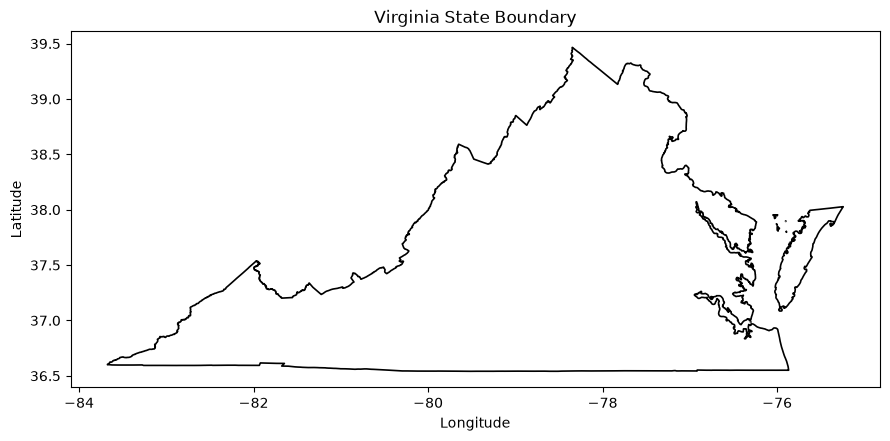


Virginia boundary summary:
   STATEFP STUSPS      NAME
41      51     VA  Virginia

Bounds:
[-83.67539511  36.5407366  -75.24245918  39.46601177]

Script completed successfully.


In [1]:
# ============================================================================
# 01_download_virginia_boundary.py
#
# Purpose:
# Download the 2024 U.S. Census state boundary file,
# extract Virginia, and save it as GeoJSON.

# Main output folder:
# /Users/gaoyujuan/REAP Dropbox/Gao yujuan/
# Virginia Tech/CALS/datasets/boundaries/virginia
# ============================================================================


# ============================================================================
# 1. Load packages
# ============================================================================

from pathlib import Path
import shutil
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import requests


# ============================================================================
# 2. Define paths
# ============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)

BOUNDARIES_DIR = BASE_DIR / "boundaries"
VIRGINIA_DIR = BOUNDARIES_DIR / "virginia"

VIRGINIA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================================
# 3. Define reusable functions
# ============================================================================

def download_file(
    url: str,
    output_path: Path,
    overwrite: bool = False,
    timeout: int = 180,
) -> Path:
    """
    Download a file from a URL.

    Parameters
    ----------
    url:
        URL of the source file.
    output_path:
        Local file path.
    overwrite:
        Replace the existing file when True.
    timeout:
        Request timeout in seconds.

    Returns
    -------
    Path
        Path to the downloaded file.
    """

    output_path = Path(output_path)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if output_path.exists() and not overwrite:
        print(f"File already exists: {output_path}")
        return output_path

    print(f"Downloading:\n{url}")

    with requests.get(
        url,
        stream=True,
        timeout=timeout,
    ) as response:

        response.raise_for_status()

        with output_path.open("wb") as file:

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if chunk:
                    file.write(chunk)

    print(f"Downloaded to:\n{output_path}")

    return output_path


def unzip_file(
    zip_path: Path,
    output_directory: Path,
    overwrite: bool = False,
) -> Path:
    """
    Extract a ZIP archive.

    Parameters
    ----------
    zip_path:
        Path to the ZIP archive.
    output_directory:
        Directory where files will be extracted.
    overwrite:
        Delete and recreate the extraction directory when True.

    Returns
    -------
    Path
        Extraction directory.
    """

    zip_path = Path(zip_path)
    output_directory = Path(output_directory)

    if output_directory.exists() and overwrite:
        shutil.rmtree(output_directory)

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(output_directory)

    print(f"Extracted files to:\n{output_directory}")

    return output_directory


# ============================================================================
# 4. Download Census state boundaries
# ============================================================================

CENSUS_STATES_URL = (
    "https://www2.census.gov/geo/tiger/GENZ2024/shp/"
    "cb_2024_us_state_500k.zip"
)

states_zip_path = (
    VIRGINIA_DIR /
    "cb_2024_us_state_500k.zip"
)

states_extract_directory = (
    VIRGINIA_DIR /
    "cb_2024_us_state_500k"
)

states_zip_path = download_file(
    url=CENSUS_STATES_URL,
    output_path=states_zip_path,
    overwrite=False,
)

states_extract_directory = unzip_file(
    zip_path=states_zip_path,
    output_directory=states_extract_directory,
    overwrite=False,
)


# ============================================================================
# 5. Locate and read the state shapefile
# ============================================================================

state_shapefiles = list(
    states_extract_directory.glob("*.shp")
)

if not state_shapefiles:
    raise FileNotFoundError(
        "No shapefile was found after extracting the Census ZIP file."
    )

state_shapefile = state_shapefiles[0]

print(f"Reading shapefile:\n{state_shapefile}")

states = gpd.read_file(state_shapefile)

print(f"Number of state records: {len(states):,}")
print(f"Original CRS: {states.crs}")


# ============================================================================
# 6. Extract Virginia
# ============================================================================

# Virginia state FIPS code = 51
virginia = states.loc[
    states["STATEFP"] == "51"
].copy()

if virginia.empty:
    raise ValueError(
        "Virginia was not found in the Census state boundary file."
    )

virginia = virginia.to_crs("EPSG:4326")

print(f"Virginia records: {len(virginia):,}")
print(f"Output CRS: {virginia.crs}")


# ============================================================================
# 7. Save Virginia boundary
# ============================================================================

virginia_geojson_path = (
    VIRGINIA_DIR /
    "virginia_boundary.geojson"
)

virginia.to_file(
    virginia_geojson_path,
    driver="GeoJSON",
)

print(
    "\nVirginia boundary saved successfully:\n"
    f"{virginia_geojson_path}"
)


# ============================================================================
# 8. Save a shapefile version
# ============================================================================

virginia_shapefile_path = (
    VIRGINIA_DIR /
    "virginia_boundary.shp"
)

virginia.to_file(
    virginia_shapefile_path,
    driver="ESRI Shapefile",
)

print(
    "\nVirginia shapefile saved successfully:\n"
    f"{virginia_shapefile_path}"
)


# ============================================================================
# 9. Plot and inspect the boundary
# ============================================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

virginia.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2,
)

ax.set_title(
    "Virginia State Boundary"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()


# ============================================================================
# 10. Print summary
# ============================================================================

print("\nVirginia boundary summary:")
print(virginia[["STATEFP", "STUSPS", "NAME"]])
print("\nBounds:")
print(virginia.total_bounds)

print("\nScript completed successfully.")